In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.em_transformer_rework import EM
from EMDPM.subject_EM import SubjectEM

np.set_printoptions(precision=4)

In [2]:
# data params
n_biomarkers = 10
t_max = 40 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)

For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.

SUBTYPE 0:
f: [0.     0.0091 0.0118 0.0281 0.013  0.0072 0.0097 0.0121 0.0127 0.    ]
a = 3.2757608804769824, b = 0.6596422758944243


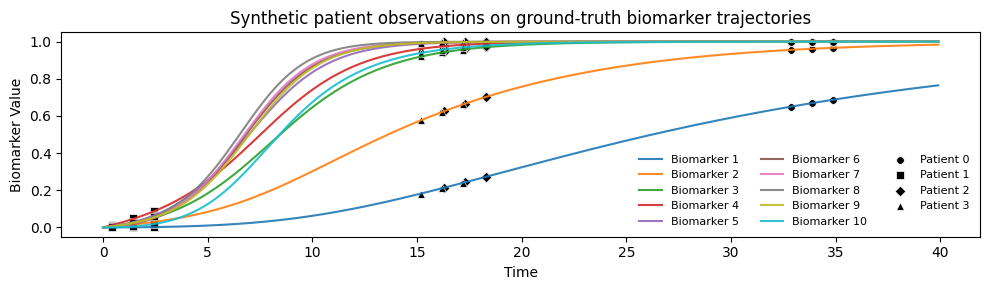

SUBTYPE 1:
f: [0.     0.     0.0138 0.0168 0.0131 0.     0.0065 0.0121 0.0062 0.0085]
a = 2.243319199025421, b = 8.1898722071885


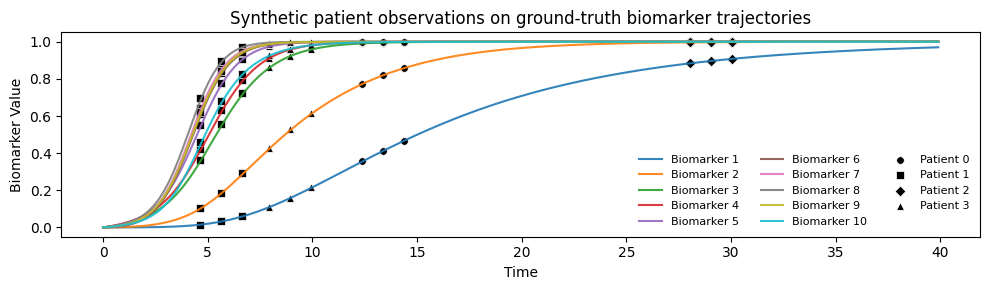

In [3]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.25, 0.50]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    
    
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    #print(f"dt shape: {dt.shape}\nids shape: {ids.shape}\ncog shape: {cog.shape}\nbeta shape: {beta_true.shape}")
    #print(beta_true)
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None) # TODO: ADD THE FUCKING TRUE LABELS
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    #  print(beta_true[::n_patient_obs][0:10])
    
X = np.asarray(X)
y = np.concatenate(y)

# print(len(X))
# print(len(y))#, y)
# print(y)

This is where the "global" fit is created, it creates a single trajectory for all patient observations and solves for individual timeshifts

100%|██████████| 30/30 [03:33<00:00,  7.13s/it]


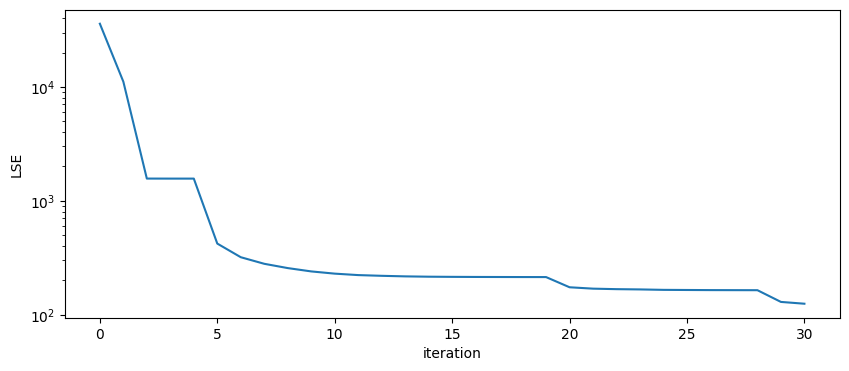

In [4]:
f_init = initialize_f_eigen(K=K) # TODO: make so that if just 1 eigen return list AND NOT list of lists
f_init = f_init[0]

em = EM(K=K, initial_f=f_init, jac_toggle=True, max_iter=30, t_max=t_max, epsilon=1e-1,
        lambda_f=1.0, lambda_cog=0.01, lambda_scalar=0.3);
em.fit(X);
plot_lse(em.lse_history)

In [5]:
print(em.final_f)
print(em.final_s)
print(em.scalar_K_)

final_f = em.final_f.copy()
final_s = em.final_s.copy()
final_scalar_K = em.scalar_K_.copy()


[0.0006 0.0268 0.0691 0.0783 0.0888 0.0908 0.0962 0.1013 0.0907 0.068 ]
[5.651  1.3707 1.0662 1.0514 1.033  1.03   1.025  1.0197 1.029  1.0655]
0.03532666548519709


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


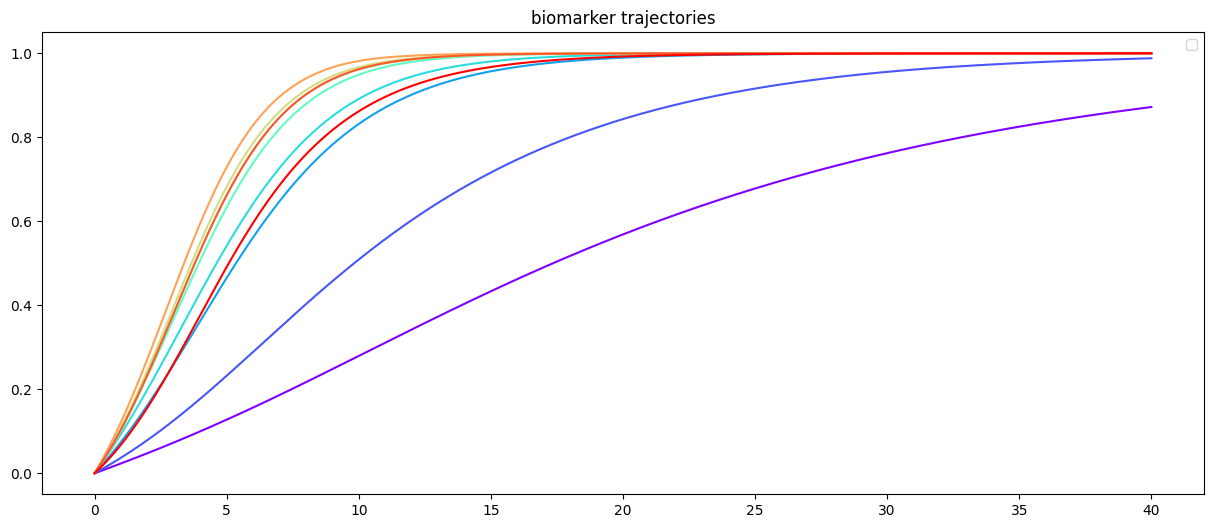

In [6]:

final_f = [0.0229, 0.0345, 0.0675, 0.0867, 0.0938, 0.0873, 0.0928, 0.1059, 0.0902, 0.0583]
final_s = [0.8899, 0.9907, 0.9953, 0.995,  0.9958, 0.9966, 0.9967, 0.9968, 0.9963, 0.9955]
final_scalar_K = 0.17304776783552925

global_fit = solve_system(x0=np.zeros(10), f=final_f, K=K, t_span=t_span, scalar_K=final_scalar_K)
plot_biomarker_trajectories(biom_trajectories=global_fit, t_span=t_span, n_biomarkers=10)

This is the start of the second fitting where the predicted timeshifts will be held constant, and biomarker trajectories are fitted for each patient.

In [7]:
## append new data to X
# final_f = em.final_f.copy()
# final_s = em.final_s.copy()
# final_scalar_K = em.scalar_K_.copy()


beta_pred = em.transform(X)   # shape: (n_patients,)

### MOST OF THIS HERE SHOULD PROBABLY BE IN TRANSFORM
assert len(beta_pred) == len(X), f"beta length {len(beta_pred)} != #patients {len(X)}"

for i, patient in enumerate(X):
    patient["beta_pred"] = float(beta_pred[i])
    patient["f_init"] = final_f                       # (n_biomarkers,)
    patient["s_init"] = final_s                       # (n_biomarkers,)
    patient["scalar_K_init"] = final_scalar_K         # scalar

print(type(X), type(X[0]))
print(X[0].keys())

Estimating beta values:   0%|          | 0/300 [00:00<?, ?it/s]

Estimating beta values: 100%|██████████| 300/300 [00:01<00:00, 224.96it/s]

<class 'numpy.ndarray'> <class 'dict'>
dict_keys(['id', 'X_obs', 'dt', 'cog', 'subtype_true', 'beta_pred', 'f_init', 's_init', 'scalar_K_init'])


In [8]:
sub_em = SubjectEM(
    K=K,
    t_max=t_max,
    step=0.01,
    max_iter=200,
    use_jacobian=True,
    lambda_f=1.0,
    lambda_scalar=0.3,
    verbose=1,
)

sub_em.fit(X)

# Access matrices for clustering
F = sub_em.forcing_matrix_          # (n_patients, n_biomarkers)
S = sub_em.s_matrix_                # (n_patients, n_biomarkers)
SK = sub_em.scalar_K_vec_           # (n_patients,)

# Or deltas vs init if you prefer
dF = sub_em.delta_forcing_matrix_
dS = sub_em.delta_s_matrix_
dSK = sub_em.delta_scalar_K_vec_

Fitting subject thetas: 100%|██████████| 300/300 [05:46<00:00,  1.15s/it]

SubjectEM completed. mean |Δf| = 0.064881


In [9]:
print(X[0].keys())

dict_keys(['id', 'X_obs', 'dt', 'cog', 'subtype_true', 'beta_pred', 'f_init', 's_init', 'scalar_K_init', 'final_f', 'final_s', 'final_scalar_K', 'delta_f', 'delta_s', 'delta_scalar_K', 'X_pred_subject'])


In [17]:
%load_ext autoreload
%autoreload 2

plot_patient_trajectories_by_biomarker(X, biomarker_indices=list(range(10)))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


NameError: name 'plot_patient_trajectories_by_biomarker' is not defined